<a href="https://colab.research.google.com/github/arshadhs/aiml-bits/blob/main/group95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Submission Deadline: **Sunday, 26 April 2026**, 11:59 PM

You are part of a research team working on **intelligent environmental sensing
systems** deployed across diverse geographies.

These systems rely on **low-cost sensors**, which often generate **noisy, inconsistent, and outlier-prone data**.

Your task is to design a **robust multi-class classification pipeline** that can infer the **environmental condition category from such imperfect sensor readings**.

The dataset provided simulates real-world imperfections such as:

• Physically inconsistent measurements

• Extreme outliers

• Mixed data types (continuous + categorical)

• Non-linear feature interactions

Your goal is not just prediction, but to **design a principled ML pipeline that is reliable under data uncertainty**.

# 1. Data Understanding & Sanity Diagnostics

a. Load the dataset and display a structured summary:

• Schema, data types, and unique value counts

• Sample records (minimum 5)

b. Identify:

• Physically impossible values (e.g., humidity > 100%)

• Suspicious ranges (e.g., extremely high wind speeds)

c. Formulate at least 3 hypotheses about potential data quality issues and their implications for model learning.

---

Physically inconsistent values were identified using logical constraints.
For example, humidity values exceeding 100% and negative visibility values were detected using conditional filtering.
Such inconsistencies indicate sensor noise and must be handled during preprocessing.

In [100]:
import numpy as np                  # For numerical operations
import pandas as pd                 # For data manipulation
import matplotlib.pyplot as plt     # For plotting
import seaborn as sns               # For enhanced data visualization
import time                         # For measuring execution time

from sklearn.model_selection import train_test_split            # For splitting data into training and test sets
from sklearn.preprocessing import StandardScaler, OneHotEncoder # For feature scaling and encoding

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [101]:
def load_database():
  '''
  Load dataset
  '''
  df = pd.read_excel('/content/drive/My Drive/Colab Notebooks/ML Assignment/PS 3.xlsx', header=0)

  # Column names were standardised to improve readability and maintain consistency across the pipeline.
  df = df.rename(columns={
    'ambient_temp_c': 'Temperature',
    'rel_humidity_pct': 'Humidity',
    'wind_velocity_kmh': 'Wind_Speed',
    'precip_intensity_pct': 'Precipitation',
    'atm_pressure_hpa': 'Pressure',
    'uv_radiation_idx': 'UV_Index',
    'visibility_range_km': 'Visibility',
    'cloud_state': 'Cloud',
    'annual_phase': 'Season',
    'terrain_category': 'Terrain',
    'env_condition_label (Target)': 'Target'
  })

  # Data Understanding
  print("\n" + "=" * 50)
  print("Data Understanding...")
  print("=" * 50)

  print("Schema / Data Types:")
  print(df.dtypes)

  print("\nSample Records:")
  print(df.head(5))

  print("\nUnique:")
  print(df.nunique())

  #print("\nInfo:")
  #print(df.info())

  #print("\nDescribe:")
  #print(df.describe())

  # Sanity Diagnostics
  print("\n" + "=" * 50)
  print("Sanity Diagnostics...")
  print("=" * 50)

  print("Humidity > 100 → ", (df['Humidity'] > 100).sum(), "rows")
  print("Visibility < 0 → ", (df['Visibility'] < 0).sum(), "rows")
  print("UV_Index < 0 → ", (df['UV_Index'] < 0).sum(), "rows")

  # ToDo : Do we need to handle it using IQR ?
  df[df['Humidity'] > 100]
  df[df['Visibility'] < 0]
  df[df['UV_Index'] < 0]

  # Suspicious Range
  print("Suspicious Wind_Speed > 150 → ", (df['Humidity'] > 150).sum(), "rows")
  print("Suspicious Temperature > 60 → ", (df['Temperature'] > 60).sum(), "rows")


  df[df['Wind_Speed'] > 150]   # extreme wind
  df[df['Temperature'] > 60]   # unrealistic temp

  return df

## Hypothesis 1 : Physically Inconsistent Sensor Values
Some sensor readings exhibit physically impossible values, such as humidity exceeding 100% or negative visibility values. These inconsistencies likely arise due to sensor malfunction or transmission errors.

Implication:
Such values can distort feature distributions and mislead model training, especially for distance-based models like k-NN and SVM, which are sensitive to abnormal magnitudes.

---
If humidity values exceed 100%, sensors may be malfunctioning.
Implication: Model may learn incorrect environmental relationships and overfit to faulty readings.

---
Extremely high wind speeds may represent unit errors (km/h vs m/s).
Implication: Model may assign excessive importance to wind feature due to scale distortion.

## Hypothesis 2 : Presence of Extreme Outliers
The dataset contains a mix of continuous and categorical variables (e.g., terrain type, cloud state), which require appropriate encoding before model training.

Implication:
Improper handling of categorical variables may result in incorrect feature representation, causing models to misinterpret relationships and degrade predictive performance.

## Hypothesis 3: Mixed Data Types and Encoding Challenges
The dataset contains a mix of continuous and categorical variables (e.g., terrain type, cloud state), which require appropriate encoding before model training.

Implication:
Improper handling of categorical variables may result in incorrect feature representation, causing models to misinterpret relationships and degrade predictive performance.
---


## Hypothesis 4 : Non- Linear Relationship

Non-linear relationships may exist between environmental variables, such as interactions between temperature and humidity or pressure and visibility.

Implication:
Linear models may fail to capture these interactions effectively, necessitating the use of non-linear models or feature engineering to improve predictive accuracy.

#2. Exploratory Data Analysis (EDA)

a. Perform univariate + bivariate + multivariate analysis:

• Distribution plots (identify skewness/heavy tails)

• Class imbalance visualization

• Interaction plots (pairwise relationships)

b. Conduct correlation + dependency analysis:

• Pearson / Spearman correlation

• Mutual Information (mandatory)

c. Answer analytically:

Does linear correlation sufficiently capture feature relationships in this dataset?

Justify using evidence.

d. Identify at least two feature interactions that may benefit non-linear models.

In [104]:
def data_analysis(df):
  # sns.histplot(df['Temperature'])
  #sns.boxplot(x='Target', y='Temperature', data=df)

  sns.histplot(df['Humidity'])
  sns.boxplot(x='Target', y='Humidity', data=df)


  ### 2(a) Univariate, Bivariate, Multivariate Analysis
#  (code + plots + explanation)

  ### 2(b) Correlation & Dependency Analysis
 # (code + heatmaps + MI + explanation)

  ### 2(c) Analytical Answer
  #(write-up)

  ### 2(d) Feature Interactions
  #(list + explanation)


  return None




#3. Preprocessing Pipeline

You must design a defensible preprocessing pipeline.

a. Handle:

• Missing values (if any)

• Outliers (MANDATORY: compare at least 2 techniques)

o e.g., IQR capping vs Isolation Forest vs Winsorization


b. Encode categorical variables:

• Compare at least two encoding techniques

(e.g., One-Hot vs Target Encoding vs Ordinal)

c. Feature Scaling:

• Compare Standardization vs Robust Scaling vs MinMax

• Justify based on distribution properties

d. Feature Engineering (Compulsory):

• Create at least 2 derived features, e.g.:

o Thermal discomfort index

o Visibility-pressure interaction

o Seasonal encoding


e. Feature Selection:

• Use at least two methods:

o Filter (Mutual Info / Chi-square)

o Embedded (Tree-based importance)


#4. Model Development

1. kNN
2. SVM
3. Decision Tree
4. Naive Bayes


a. Train-test splits:

• 80:20 (mandatory)

• One additional custom split (justify choice)

b. Implement at least 4 models:

• k-NN

• SVM

• Decision Tree


• Naïve Bayes

c. Additionally (IIT-level requirement):

• Include at least one ensemble model:

o Random Forest / Gradient Boosting


d. Hyperparameter tuning:

• Use GridSearchCV or RandomizedSearchCV

• Clearly justify:

o Parameter ranges

o Evaluation strategy


e. Cross-validation:

• Use k-fold CV (k ≥ 5)

• Explain variance in performance

#5. Evaluation & Analysis

a. Evaluate using:

• Accuracy

• Precision, Recall, F1-score

• Confusion Matrix

• Macro vs Weighted metrics (important for imbalance)

b. Provide:

• Comparative table of all models

• Ranking based on multiple criteria

c. Analytical questions:

1. Which model is most robust to noise and outliers? Why?

2. Which model benefits most from feature engineering?

3. Does increased complexity always improve performance?

#Main Execution

In [105]:
def main():
  df = load_database()

  data_analysis(df)


Data Understanding...
Schema / Data Types:
Temperature        int64
Humidity           int64
Wind_Speed       float64
Precipitation      int64
Cloud             object
Pressure         float64
UV_Index           int64
Season            object
Visibility       float64
Terrain           object
Target            object
dtype: object

Sample Records:
   Temperature  Humidity  Wind_Speed  Precipitation          Cloud  Pressure  \
0           14        73         9.5             82  partly cloudy   1010.82   
1           39        96         8.5             71  partly cloudy   1011.43   
2           30        64         7.0             16          clear   1018.72   
3           38        83         1.5             82          clear   1026.25   
4           27        74        17.0             66       overcast    990.67   

   UV_Index  Season  Visibility   Terrain  Target  
0         2  Winter         3.5    inland   Rainy  
1         7  Spring        10.0    inland  Cloudy  
2         5  

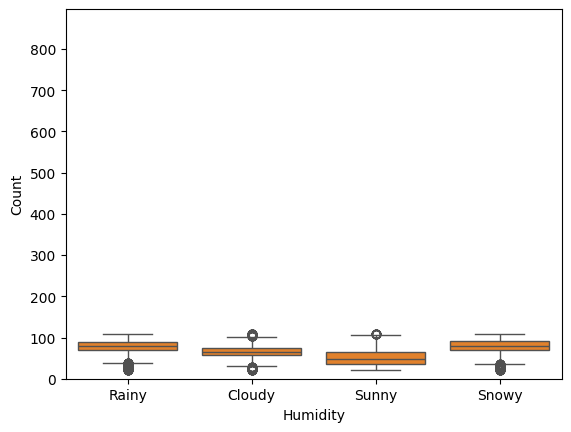

In [106]:
if __name__ == '__main__':
    main()

# Contribution Report